# Training Neural Networks

The primary goal of training a neural network is to find a set of weights that minimise the error or loss of the model. While simple models like linear regression have direct formulas to find these weights, neural networks are too complex for that, requiring an interative procedure to find the best parameters.

## The Loss Function
The loss function is the mathematical yardstick used to measure how far off your models predictions are from the actual values.
- Small Loss - Indicates the model is making good predictions
- Large Loss - Indicates poor predictions

### Common Loss Formulas
- Mean Squared Error - Used for Regression

$\frac{1}{2m}\sum_{i=1}^{m}(y^{(i)}-\hat{y^{(i)}})^{2}$

- Binary Cross-Entropy - Used for Logistic/Binary Classification

$L(w)=-\frac{1}{m}[\sum_{i=1}^{m}-y^{(i)}log(f_{w}(x^{(i)}))-(1-y^{(i)})log(1-f_{w}(x^{(i)}))]$

### Loss Vs Metrics
It is vital to distinguish between what the machine optimises and what humans care about.
- Loss - Must be differentiable so the computer can calculate gradients and improve.
- Metrics - These are for human interpretation to see if the model is actually performing well. You cannot directly optimise accuracy because it isnt differentiable.

### Loss Functions Python

In [9]:
# No need to reinstall numpy if it's already done, but keeping it for safety
%pip install numpy

import numpy as np

# --- 1. SETUP DUMMY DATA ---
# y_true: The actual correct answers
# y_pred: What our "model" guessed
y_true = np.array([1.0, 0.0, 1.0, 1.0])
y_pred = np.array([0.9, 0.2, 0.8, 0.4]) 

# --- 2. MEAN SQUARED ERROR (MSE) ---
# Formula: average of (true - pred)^2
def calculate_mse(true, pred):
    squared_errors = (true - pred) ** 2
    return np.mean(squared_errors)

# --- 3. BINARY CROSS-ENTROPY (BCE) ---
# Formula: -avg(y*log(p) + (1-y)*log(1-p))
def calculate_bce(true, pred):
    # Epsilon prevents log(0) which is undefined (infinity)
    epsilon = 1e-15
    pred = np.clip(pred, epsilon, 1 - epsilon)
    
    loss = -np.mean(true * np.log(pred) + (1 - true) * np.log(1 - pred))
    return loss

# --- EXECUTION ---
mse_result = calculate_mse(y_true, y_pred)
bce_result = calculate_bce(y_true, y_pred)

print(f"Regression Loss (MSE): {mse_result:.4f}")
print(f"Classification Loss (BCE): {bce_result:.4f}")

Note: you may need to restart the kernel to use updated packages.
Regression Loss (MSE): 0.1125
Classification Loss (BCE): 0.3670


## Gradient Descent & Learning Rates

Imagine the loss function as a 3D landscape of hills and valleys. The current weights represent the standing position on that surface.
- The Goal - Find the lowest point in the valley (the minimum loss)
- The Strategy - Since we cant always solve for the minimum directly, we use **Gradient Descent** which is an interative procedure where we take small steps downhill until we reach the bottom.

### The Gradient
The gradient is a vector that points in the direction of the steepest increase in loss. To go downhill, we move in the opposite direction of the gradient.

### The Learning Rate $\alpha$
The learning rate is a crucial hyperparameter that determines the size of the steps we take
- Too Large - We might overshoot the valley, causing the training to bounce around or fail entirely.
- Too Small - We will take tiny steps, but this can make training extremely slow

### Weight Update Rule
$$w_{new} = w_{old} - \alpha \frac{\partial L}{\partial w}$$

### Simulating Gradient Descent

Note: you may need to restart the kernel to use updated packages.
Step 1: w = 3.2000, loss = 10.2400
Step 2: w = 2.5600, loss = 6.5536
Step 3: w = 2.0480, loss = 4.1943
Step 4: w = 1.6384, loss = 2.6844
Step 5: w = 1.3107, loss = 1.7180
Step 6: w = 1.0486, loss = 1.0995
Step 7: w = 0.8389, loss = 0.7037
Step 8: w = 0.6711, loss = 0.4504
Step 9: w = 0.5369, loss = 0.2882
Step 10: w = 0.4295, loss = 0.1845
Step 11: w = 0.3436, loss = 0.1181
Step 12: w = 0.2749, loss = 0.0756
Step 13: w = 0.2199, loss = 0.0484
Step 14: w = 0.1759, loss = 0.0309
Step 15: w = 0.1407, loss = 0.0198
Step 16: w = 0.1126, loss = 0.0127
Step 17: w = 0.0901, loss = 0.0081
Step 18: w = 0.0721, loss = 0.0052
Step 19: w = 0.0576, loss = 0.0033
Step 20: w = 0.0461, loss = 0.0021


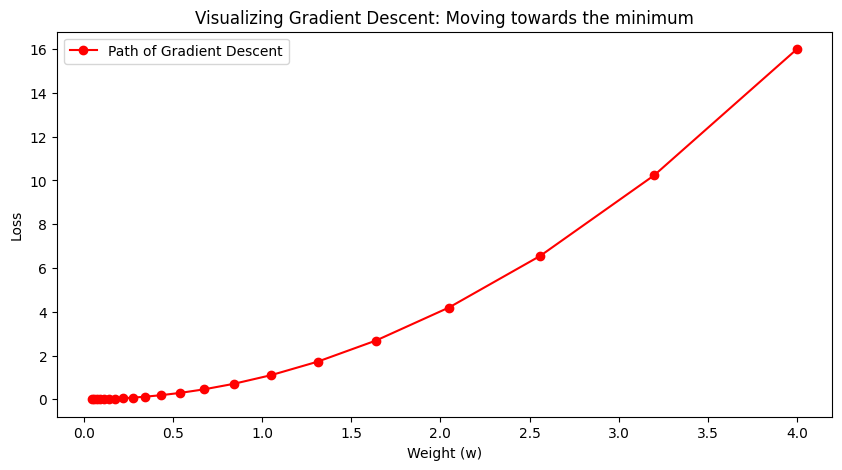

In [10]:
%pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt

# 1. Define a simple Loss Function: L(w) = w^2
# The minimum of this function is clearly at w = 0
def loss_function(w):
    return w**2

# 2. Define the Gradient: dL/dw = 2w
def gradient(w):
    return 2 * w

# 3. Parameters
learning_rate = 0.1  # Try changing this to 0.01 or 0.9 to see what happens!
current_w = 4.0      # Starting point
epochs = 20          # Number of steps

# Store history for plotting
w_history = [current_w]
loss_history = [loss_function(current_w)]

# 4. The Training Loop (Gradient Descent)
for i in range(epochs):
    # Calculate the gradient at current position
    grad = gradient(current_w)
    
    # Update the weight: w_new = w_old - alpha * gradient
    current_w = current_w - (learning_rate * grad)
    
    # Save history
    w_history.append(current_w)
    loss_history.append(loss_function(current_w))
    
    print(f"Step {i+1}: w = {current_w:.4f}, loss = {loss_function(current_w):.4f}")

# 5. Visualize the "Descent"
plt.figure(figsize=(10, 5))
plt.plot(w_history, loss_history, 'ro-', label='Path of Gradient Descent')
plt.title("Visualizing Gradient Descent: Moving towards the minimum")
plt.xlabel("Weight (w)")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Epochs and Mini-Batch Gradient Descent
An epoch is one complete pass through the entire training dataset. The process is that during one epoch, the algorithm sees every single training example once and uses them to update the models weights.

Think of it as a for loop that wraps around the data processing steps.

### The provided notes highlight three main ways to show data to the network
- Batch Gradient Descent - The batch size is the entire training set. Once update is made only after seeing all samples. It is memory-intensive for large datasets.
- Stoachastic Gradient Descent (SGD) - The batch size is 1. The model updates its weights after every single sample. This is fast but noisy because individual samples might not represent the whole group well.
- Mini-Batch Gradient Descent (The Standard) - You split the data into small chunks, common sizes are like 32, 64 or 128. This provides a balance between the stability of Batch GD and the speed of SGD.

$$\text{Updates} = \frac{\text{Total Training Samples}}{\text{Batch Size}}$$

### Python Simulation

In [11]:
%pip install numpy

import numpy as np

# 1. Create a larger dummy dataset (100 samples)
X = np.random.randn(100, 1)
y = 2 * X + 1 + np.random.randn(100, 1) * 0.1  # Target is roughly y = 2x + 1

# 2. Training Hyperparameters
batch_size = 20  # Process 20 samples at a time
epochs = 5
learning_rate = 0.01
weight = 0.0

print(f"Total samples: {len(X)}")
print(f"Batch size: {batch_size}")
print(f"Updates per epoch: {len(X) // batch_size}")
print("-" * 30)

# 3. The Nested Training Loop
for epoch in range(epochs):
    # Step 1: Shuffle the data at the start of each epoch
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    epoch_loss = 0
    
    # Step 2: Iterate over Mini-Batches
    for i in range(0, len(X), batch_size):
        # Grab a chunk of data
        X_batch = X_shuffled[i : i + batch_size]
        y_batch = y_shuffled[i : i + batch_size]
        
        # Forward pass (prediction & local loss)
        predictions = X_batch * weight
        batch_loss = np.mean((y_batch - predictions)**2)
        epoch_loss += batch_loss
        
        # Calculate Gradient for the batch
        # dL/dw = -2/N * sum(X * (y - pred))
        gradient = -2 * np.mean(X_batch * (y_batch - predictions))
        
        # Update Weight (The Formula)
        weight = weight - (learning_rate * gradient)
        
    print(f"Epoch {epoch+1}/{epochs} - Avg Loss: {epoch_loss / (len(X)/batch_size):.4f} - Updated Weight: {weight:.4f}")

Note: you may need to restart the kernel to use updated packages.
Total samples: 100
Batch size: 20
Updates per epoch: 5
------------------------------
Epoch 1/5 - Avg Loss: 4.6817 - Updated Weight: 0.1783
Epoch 2/5 - Avg Loss: 4.0982 - Updated Weight: 0.3415
Epoch 3/5 - Avg Loss: 3.6004 - Updated Weight: 0.4916
Epoch 4/5 - Avg Loss: 3.1881 - Updated Weight: 0.6294
Epoch 5/5 - Avg Loss: 2.8331 - Updated Weight: 0.7552


## The Model Life Cycle
The standard workflow for building and training a neural network consists of five primary steps
- Define the architecture: Choose the number of layers and neurons
- Compile: Select the loss function, optimiser like adam and metrics like accuracy
- Fit: Run the training loop on the data
- Evaluate: Test the models performance on unseen data
- Predict: Use the trained model to make new predictions

### The Inner Training Loop
While `model.fit()` automates the process, every single training step for a mini-batch involves three critical phases:

#### The Forward Pass
- Data flows from input to output through each layer
- The model calculates predictions and the resulting Loss
- Crucial Step: All intermediate values (activations) are saved because they are required for the next phase

$$z_{1} = W_{1}x + b_{1}$$
$$h = \text{ReLU}(z_{1})$$
$$z_{2} = W_{2}h + b_{2}$$
$$\hat{y} = \text{Activation}(z_{2})$$

#### The Backward Pass
- Gradient flow in reverse from right to left
- The algorithm calculates exactly how much each weight contributed to the total error
- This is far more memory-intensive than prediction because of the saved activations

#### The Weight Update
The optimiser uses the gradients from the backward pass to adjust every weight slightly to reduce the loss

### Python Code Simulation

In [12]:
%pip install numpy tensorflow

import tensorflow as tf
from tensorflow.keras import layers, Sequential

# 1. Define the Model Architecture [cite: 43]
# We use the Sequential API to stack layers
model = Sequential([
    layers.Dense(64, activation='relu', input_shape=(10,)), # Hidden Layer 1
    layers.Dense(32, activation='relu'),                   # Hidden Layer 2
    layers.Dense(1, activation='sigmoid')                  # Output Layer (Binary)
])

# 2. Compile the Model [cite: 65, 67]
# Choosing the 'engine' (optimizer) and the 'yardstick' (loss)
model.compile(
    optimizer='adam',                # Recommended default [cite: 37]
    loss='binary_crossentropy',      # Standard for binary classification [cite: 67]
    metrics=['accuracy']
)

# 3. Fit the Model (Training) [cite: 69]
# This triggers the Forward and Backward passes automatically
# 'validation_split' holds out 20% of data to check for overfitting [cite: 69]
print("Starting training...")
# Note: In a real scenario, you would pass your actual X_train and y_train here.
# history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# 4. Summarize the Architecture
model.summary()

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow
Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'tensorflow'

## Overfitting vs Underfitting
To know how to improve the model, you must first diagnose its behvaiour using Learning Curves (plots of training vs validation loss over epochs)

### Underfitting
- What it looks like: Both training and validation loss remain high and dont decrease much
- The Cause: The model is not complex enough to capture the patterns in the data
- The Fix:
    - Add more layers or more neurons per layer
    - Train for more epochs
    - Reduce regularisation
    - Ensure the learning rate is not set too low

### Overfitting
- What it looks like: Training loss is very low, but validation loss stops decreasing and starts to diverge upward
- The Cause: The model has memorised the noise in the training data rather than learning general patterns
- The Fix:
    - Get more training data (the most effective option)
    - Add Regularisation (L2 or Dropout)
    - Reduce the network size
    - Use Early Stopping

### Regularisation Techniques
Regularisation is any technique used to reduce overfitting by discouraging the model from becoming overly complex.

#### L2 Regularisation (Weight Decay)
This adds a penalty term to the loss function based on the size of the weights, forcing the network to prefer smaller weights

$$L_{reg} = L_{original} + \lambda \sum w^2$$

- $\lambda$: The regularisation strength. A higher value penalises large weights more strictly.

#### Early Stopping
Instead of guessing the number of epochs, the model monitors the validation loss and stops training automatically when it stops improving
- Patience: A hyperparameter that defines how many epochs to wait for improvement before giving up

### Python Simulation

In [ ]:
%pip install tensorflow numpy

import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks

# 1. Define Model with L2 Regularization
model = tf.keras.Sequential([
    # kernel_regularizer adds the L2 penalty to this specific layer
    layers.Dense(128, activation='relu', 
                 kernel_regularizer=regularizers.l2(0.01), 
                 input_shape=(10,)),
    layers.Dense(64, activation='relu', 
                 kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Define Early Stopping
# restore_best_weights ensures that at the end, you keep the "best" version
# of the model rather than the one from the very last (possibly overfitted) epoch.
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# 3. Fit the model using the callback
print("Training with Early Stopping and L2 Regularization...")
# history = model.fit(X_train, y_train, 
#                     epochs=1000, 
#                     validation_split=0.2, 
#                     callbacks=[early_stop])